In [1]:
import lightgbm



In [2]:
lightgbm.__version__

'4.6.0'

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    precision_score,
    roc_auc_score # Area Under the Receiver Operating Characteristic Curve (ROC AUC) score -zalężność między prawdziwymi TPR a FPR
)
import lightgbm as lgb

In [4]:
hr_data = pd.read_csv("../datasets/hr_analytics.csv")

In [15]:
hr_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54735 entries, 0 to 54734
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   department            54735 non-null  category
 1   region                54735 non-null  category
 2   education             52329 non-null  category
 3   gender                54735 non-null  category
 4   recruitment_channel   54735 non-null  category
 5   no_of_trainings       54735 non-null  int64   
 6   age                   54735 non-null  int64   
 7   previous_year_rating  50616 non-null  float64 
 8   length_of_service     54735 non-null  int64   
 9   awards_won?           54735 non-null  int64   
 10  avg_training_score    54735 non-null  int64   
 11  is_promoted           54735 non-null  int64   
dtypes: category(5), float64(1), int64(6)
memory usage: 3.2 MB


In [7]:
hr_data.isnull().sum()

employee_id                0
department                 0
region                     0
education               2406
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4119
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [9]:
hr_data = hr_data.drop("employee_id", axis=1)

In [12]:
categorical_features = hr_data.select_dtypes(exclude="number").columns.tolist()
categorical_features

['department', 'region', 'education', 'gender', 'recruitment_channel']

In [13]:
hr_data[categorical_features] = hr_data[categorical_features].astype("category")

In [16]:
target_counts = hr_data["is_promoted"].value_counts().sort_index()

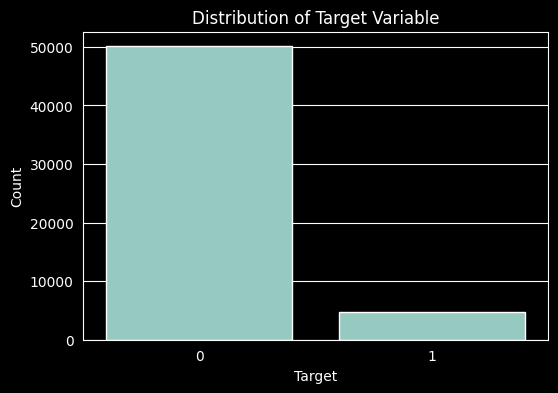

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax)
ax.set_xlabel("Target")
ax.set_ylabel("Count")
ax.set_title("Distribution of Target Variable")

plt.show()

In [19]:
X = hr_data.drop("is_promoted", axis=1)
y = hr_data["is_promoted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [20]:
X_train.shape, X_test.shape

((38314, 11), (16421, 11))

In [22]:
lgbm_clf = lightgbm.LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    num_leaves=31,
    n_estimators=100,
    random_state=42,
    verbose=-1
)
lgbm_clf.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [23]:
def compute_metrics(clf):
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC Score": roc_auc_score(y_test, y_pred_proba),
    }

    print("Evaluation Metrics:")
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    return metrics

In [24]:
compute_metrics(lgbm_clf)

Evaluation Metrics:
Accuracy: 0.9406
Precision: 0.9568
Recall: 0.3167
F1 Score: 0.4758
ROC-AUC Score: 0.8257


{'Accuracy': 0.9405639120638207,
 'Precision': 0.9568034557235421,
 'Recall': 0.3166547533952823,
 'F1 Score': 0.4758324382384533,
 'ROC-AUC Score': 0.8257147320456087}

In [26]:

lgbm_clf = lightgbm.LGBMClassifier(
    objective="binary",
    learning_rate=0.01,
    num_leaves=31,
    max_bin=400,
    n_estimators=1000,
    random_state=42,
    verbose=-1
)
lgbm_clf.fit(X_train, y_train)

compute_metrics(lgbm_clf)

Evaluation Metrics:
Accuracy: 0.9408
Precision: 0.9457
Recall: 0.3238
F1 Score: 0.4824
ROC-AUC Score: 0.8256


{'Accuracy': 0.9408075025881493,
 'Precision': 0.9457202505219207,
 'Recall': 0.32380271622587564,
 'F1 Score': 0.48242811501597443,
 'ROC-AUC Score': 0.8256400738530832}

In [29]:
lgbm_clf = lightgbm.LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    n_estimators=500,
    random_state=42,
    verbose=-1
)
lgbm_clf.fit(X_train, y_train)

compute_metrics(lgbm_clf)

Evaluation Metrics:
Accuracy: 0.8434
Precision: 0.2953
Recall: 0.6047
F1 Score: 0.3968
ROC-AUC Score: 0.8184


{'Accuracy': 0.8433712928567079,
 'Precision': 0.29528795811518327,
 'Recall': 0.6047176554681916,
 'F1 Score': 0.3968105065666041,
 'ROC-AUC Score': 0.8183637312879876}

In [30]:
X_train_es, X_val, y_train_es, y_val = train_test_split(
    X_train, y_train, test_size=0.30, random_state=42, stratify=y_train)

X_train_es.shape, X_val.shape

((26819, 11), (11495, 11))

In [35]:
lgbm_clf = lgb.LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    n_estimators=3000,
    random_state=42,
    verbose=1
)
lgbm_clf.fit(X_train, y_train,
             eval_metric="f1",
             eval_set=[(X_val, y_val)],
             callbacks=[lgb.early_stopping(stopping_rounds=5)])


compute_metrics(lgbm_clf)

[LightGBM] [Info] Number of positive: 3263, number of negative: 35051
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 213
[LightGBM] [Info] Number of data points in the train set: 38314, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[3000]	valid_0's binary_logloss: 0.100851
Evaluation Metrics:
Accuracy: 0.9004
Precision: 0.4219
Recall: 0.4575
F1 Score: 0.4390
ROC-AUC Score: 0.7935


{'Accuracy': 0.9003714755496012,
 'Precision': 0.4218852999340804,
 'Recall': 0.45746962115796996,
 'F1 Score': 0.438957475994513,
 'ROC-AUC Score': 0.7935443788947523}